# Business Impact and Final Threshold

This notebook selects a decision threshold on validation data under an explicit illustrative cost scenario. The scenario assumptions are not observed business facts. After the threshold is frozen, the held-out test set is evaluated once and the result is stored for reuse.


In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.business_metrics import BusinessCostAssumptions, cost_sensitivity_table
from src.data import load_dataset, split_dataset
from src.evaluation import classification_metrics
from src.models import build_xgboost
from src.preprocessing import build_tree_preprocessor, fit_transform_splits

random_state = 42


In [2]:
transaction_dataset = load_dataset(project_root / "data" / "creditcard.csv")
(
    training_features,
    validation_features,
    test_features,
    training_labels,
    validation_labels,
    test_labels,
) = split_dataset(transaction_dataset, random_state=random_state)

tree_preprocessor = build_tree_preprocessor(training_features.columns.tolist())
(
    tree_training_features,
    tree_validation_features,
    tree_test_features,
    _,
) = fit_transform_splits(
    tree_preprocessor,
    training_features,
    validation_features,
    test_features,
)

fraud_count = int(training_labels.sum())
legitimate_count = len(training_labels) - fraud_count

xgboost_model = build_xgboost(random_state=random_state)
xgboost_model.set_params(scale_pos_weight=legitimate_count / fraud_count)
xgboost_model.fit(tree_training_features, training_labels)

validation_scores = xgboost_model.predict_proba(tree_validation_features)[:, 1]


In [3]:
# Illustrative scenario only; these values are configurable assumptions, not observed operational facts.
assumptions = BusinessCostAssumptions(
    missed_fraud_multiplier=1.0,
    false_positive_review_cost=5.0,
    recoverable_fraud_fraction=0.0,
)

quantile_thresholds = np.quantile(validation_scores, np.linspace(0.0, 1.0, 1001))
threshold_candidates = np.unique(np.concatenate(([0.0, 1.0], quantile_thresholds)))

validation_cost_table = cost_sensitivity_table(
    validation_labels,
    validation_scores,
    validation_features["Amount"].to_numpy(),
    assumptions=assumptions,
    thresholds=threshold_candidates,
)

selected_cost_row = validation_cost_table.loc[
    validation_cost_table["total_expected_cost"].idxmin()
]
selected_threshold = float(selected_cost_row["threshold"])

selected_cost_row


threshold                 0.648454
false_negatives          18.000000
false_positives          34.000000
missed_fraud_cost      4539.770000
false_positive_cost     170.000000
total_expected_cost    4709.770000
Name: 999, dtype: float64

In [4]:
validation_metrics = classification_metrics(
    validation_labels,
    validation_scores,
    threshold=selected_threshold,
)

validation_metrics


{'threshold': 0.6484539222717475,
 'roc_auc': 0.9831074472945537,
 'pr_auc': 0.8071632995879947,
 'precision': 0.7017543859649122,
 'recall': 0.8163265306122449,
 'f1': 0.7547169811320755,
 'tn': 56829,
 'fp': 34,
 'fn': 18,
 'tp': 80}

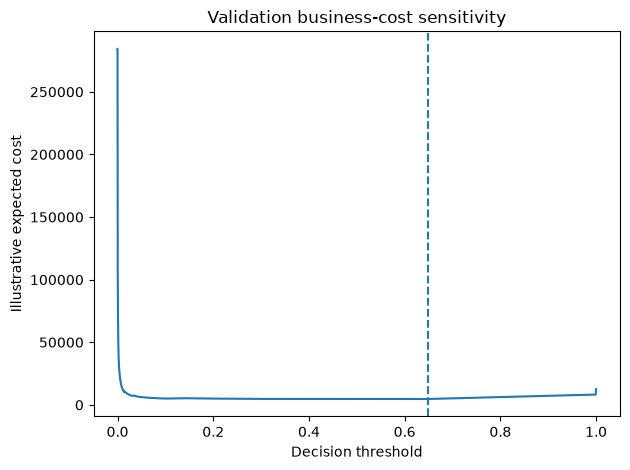

In [5]:
figure_directory = project_root / "outputs" / "figures"
metrics_directory = project_root / "outputs" / "metrics"
figure_directory.mkdir(parents=True, exist_ok=True)
metrics_directory.mkdir(parents=True, exist_ok=True)

validation_cost_table.to_csv(
    metrics_directory / "validation_business_cost_sensitivity.csv",
    index=False,
)

plt.figure()
plt.plot(
    validation_cost_table["threshold"],
    validation_cost_table["total_expected_cost"],
)
plt.axvline(selected_threshold, linestyle="--")
plt.xlabel("Decision threshold")
plt.ylabel("Illustrative expected cost")
plt.title("Validation business-cost sensitivity")
plt.tight_layout()
plt.savefig(
    figure_directory / "validation_business_cost_sensitivity.png",
    dpi=160,
    bbox_inches="tight",
)
plt.show()


In [6]:
threshold_decision = {
    "model": "XGBoost",
    "selection_split": "validation",
    "selection_rule": "minimum illustrative expected cost",
    "threshold": selected_threshold,
    "assumptions": {
        "missed_fraud_multiplier": assumptions.missed_fraud_multiplier,
        "false_positive_review_cost": assumptions.false_positive_review_cost,
        "recoverable_fraud_fraction": assumptions.recoverable_fraud_fraction,
        "note": "Illustrative scenario assumptions, not observed business facts.",
    },
    "validation_metrics": validation_metrics,
}

(metrics_directory / "selected_business_threshold.json").write_text(
    json.dumps(threshold_decision, indent=2),
    encoding="utf-8",
)

threshold_decision


{'model': 'XGBoost',
 'selection_split': 'validation',
 'selection_rule': 'minimum illustrative expected cost',
 'threshold': 0.6484539222717475,
 'assumptions': {'missed_fraud_multiplier': 1.0,
  'false_positive_review_cost': 5.0,
  'recoverable_fraud_fraction': 0.0,
  'note': 'Illustrative scenario assumptions, not observed business facts.'},
 'validation_metrics': {'threshold': 0.6484539222717475,
  'roc_auc': 0.9831074472945537,
  'pr_auc': 0.8071632995879947,
  'precision': 0.7017543859649122,
  'recall': 0.8163265306122449,
  'f1': 0.7547169811320755,
  'tn': 56829,
  'fp': 34,
  'fn': 18,
  'tp': 80}}

In [7]:
final_test_path = metrics_directory / "final_test_metrics.json"

if final_test_path.exists():
    final_test_result = json.loads(final_test_path.read_text(encoding="utf-8"))
    print("Final held-out test metrics already exist; loading stored result without rescoring test data.")
else:
    test_scores = xgboost_model.predict_proba(tree_test_features)[:, 1]
    test_metrics = classification_metrics(
        test_labels,
        test_scores,
        threshold=selected_threshold,
    )
    final_test_result = {
        "model": "XGBoost",
        "threshold_source": "validation business-cost selection",
        "threshold": selected_threshold,
        "test_metrics": test_metrics,
    }
    final_test_path.write_text(
        json.dumps(final_test_result, indent=2),
        encoding="utf-8",
    )

final_test_result


{'model': 'XGBoost',
 'threshold_source': 'validation business-cost selection',
 'threshold': 0.6484539222717475,
 'test_metrics': {'threshold': 0.6484539222717475,
  'roc_auc': 0.976323476042098,
  'pr_auc': 0.8556686156243153,
  'precision': 0.7545454545454545,
  'recall': 0.8383838383838383,
  'f1': 0.7942583732057417,
  'tn': 56836,
  'fp': 27,
  'fn': 16,
  'tp': 83}}

## Interpretation

Model choice and threshold selection are completed without using the held-out test labels. The final test result is written once and then reused on later notebook executions. The cost analysis is scenario-based: changing the review cost, missed-fraud multiplier, or recoverable fraction can change the preferred threshold.
